#DIŞ ŞOKLARIN HAVACILIK SEKTÖRÜNE ETKİSİ: ANTALYA HAVALİMANI DIŞ HAT YOLCU TRAFİĞİNİN ZAMAN SERİSİ VE EKONOMETRİK MODELLEME İLE ANALİZİ (2018-2023)

In [5]:
# veri bilimi kütüphanesini yükleyelim
import pandas as pd

In [6]:
#python ayracı virgül mü noktalı virgül mü otomatik bulsun
df=pd.read_csv("antalya_ucus_verisi.csv",sep=None,engine="python")

In [7]:
#sütun isimlerinde boşluk olma ihtimaline karşın boşlukları silelim
df.columns=df.columns.str.strip()

In [8]:
#tarih sütununu parçalayıp ay ve yıl olarak yazalım
df["Tarih"]=pd.to_datetime(df["Tarih"])
df["Yil"]=df["Tarih"].dt.year
df["Ay"]=df["Tarih"].dt.month

In [9]:
#kümülatif veriyi aylık veriye dönüştürmek için boş bir liste tanımlayalım
aylik_yolcu_listesi=[]


In [10]:
#binlik ayraç noktalarını temizleyip tam sayıya dönüştürme
df["kumulatif_yolcu"]=df["kumulatif_yolcu"].astype(str).str.replace(".","",regex=False).astype(int)

In [11]:
#döngü ile aylık net rakamları hesaplama
for i in range(len(df)):
  if df.loc[i,"Ay"]==1:
    aylik_yolcu_listesi.append(df.loc[i,"kumulatif_yolcu"])
  else:
    aylik_yolcu_listesi.append(df.loc[i,"kumulatif_yolcu"]-df.loc[i-1,"kumulatif_yolcu"])

In [33]:
#elde ettiğimiz net aylık rakamları yeni bir sütun olarak ekleyelim
df["Aylik_yolcu"]=aylik_yolcu_listesi
display(df.head())

,Tarih,kumulatif_yolcu,kriz_durumu,Unnamed: 3,Yil,Ay,Aylik_yolcu
0,2018-01-01,201588,0,NaN,2018,1,201588
1,2018-02-01,385751,0,NaN,2018,2,184163
2,2018-03-01,768145,0,NaN,2018,3,382394
3,2018-04-01,1895165,0,NaN,2018,4,1127020
4,2018-05-01,4686014,0,NaN,2018,5,2790849


In [13]:
#veri görselleştirme için gerekli kütüphaneleri ekleyelim
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# grafik boyutunu ve temasını profosyonel bir görünüme ayarla
plt.figure(figsize=(15,6))
sns.set_theme(style="whitegrid")

<Figure size 1500x600 with 0 Axes>

In [15]:
#Türkçe ay isimlerini tanımlayalım
tr_aylar={1:"Ocak",2:"Şubat",3:"Mart",4:"Nisan",5:"Mayıs",6:"Haziran",7:"Temmuz",8:"Ağustos",9:"Eylül",10:"Ekim",11:"Kasım",12:"Aralık"}

In [18]:
#veriyi tarih sütununa göre sıralayalım ve türkçe isimleri oluşturalım
df_sorted=df.sort_values(by="Tarih").copy()
df_sorted["yil_sayi"]=df_sorted["Tarih"].dt.year
df_sorted["ay_sayi"]=df_sorted["Tarih"].dt.month
df_sorted["tr_ay_adi"]=df_sorted["ay_sayi"].map(tr_aylar)
df_sorted["tam_tarih_etiket"]=df_sorted["tr_ay_adi"]+""+df_sorted["yil_sayi"].astype(str)

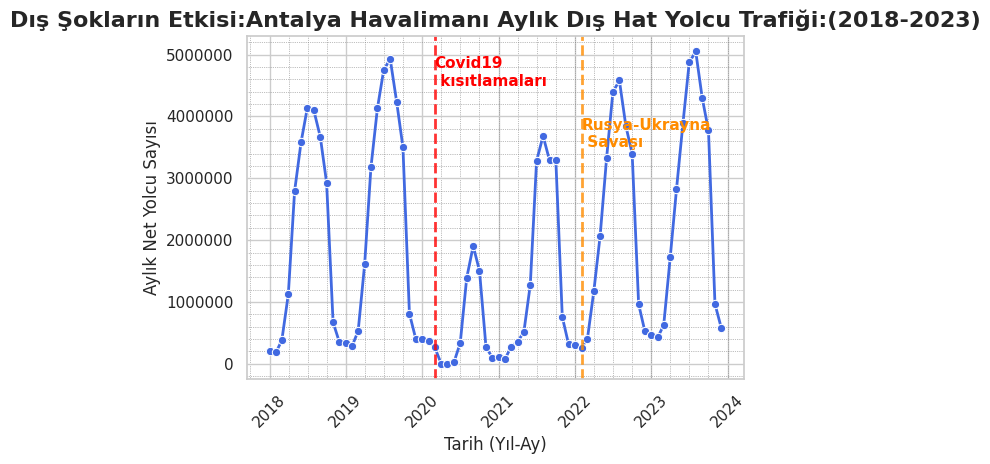

In [21]:
#aylık yolcu sayısını gösteren time series grafiği
sns.lineplot(data=df,x="Tarih",y="Aylik_yolcu",marker="o",color="royalblue",linewidth=2)
plt.title("Dış Şokların Etkisi:Antalya Havalimanı Aylık Dış Hat Yolcu Trafiği:(2018-2023)",fontsize=16,fontweight="bold")
plt.xlabel("Tarih (Yıl-Ay)",fontsize=12)
plt.ylabel("Aylık Net Yolcu Sayısı",fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.0f}"))
plt.xticks(rotation=45)
#covid_19 pandemisi (MART 2020)
covid_tarih=pd.to_datetime("2020-03-01")
plt.axvline(x=covid_tarih,color="red",linestyle="--",linewidth=2,alpha=0.8)
plt.text(covid_tarih,4500000,"Covid19\n kısıtlamaları",color="red",fontsize=11,fontweight="bold",ha="left")

#RUSYA-UKRAYNA Savaşı
savas_tarih=pd.to_datetime("2022-02-01")
plt.axvline(x=savas_tarih,color="darkorange",linestyle="--",linewidth=2,alpha=0.8)
plt.text(savas_tarih,3500000,"Rusya-Ukrayna\n Savaşı",color="darkorange",fontsize=11,fontweight="bold",ha="left")

plt.minorticks_on()
plt.grid(which="minor",linestyle=":",linewidth="0.5",color="gray")
plt.tight_layout()
plt.show()

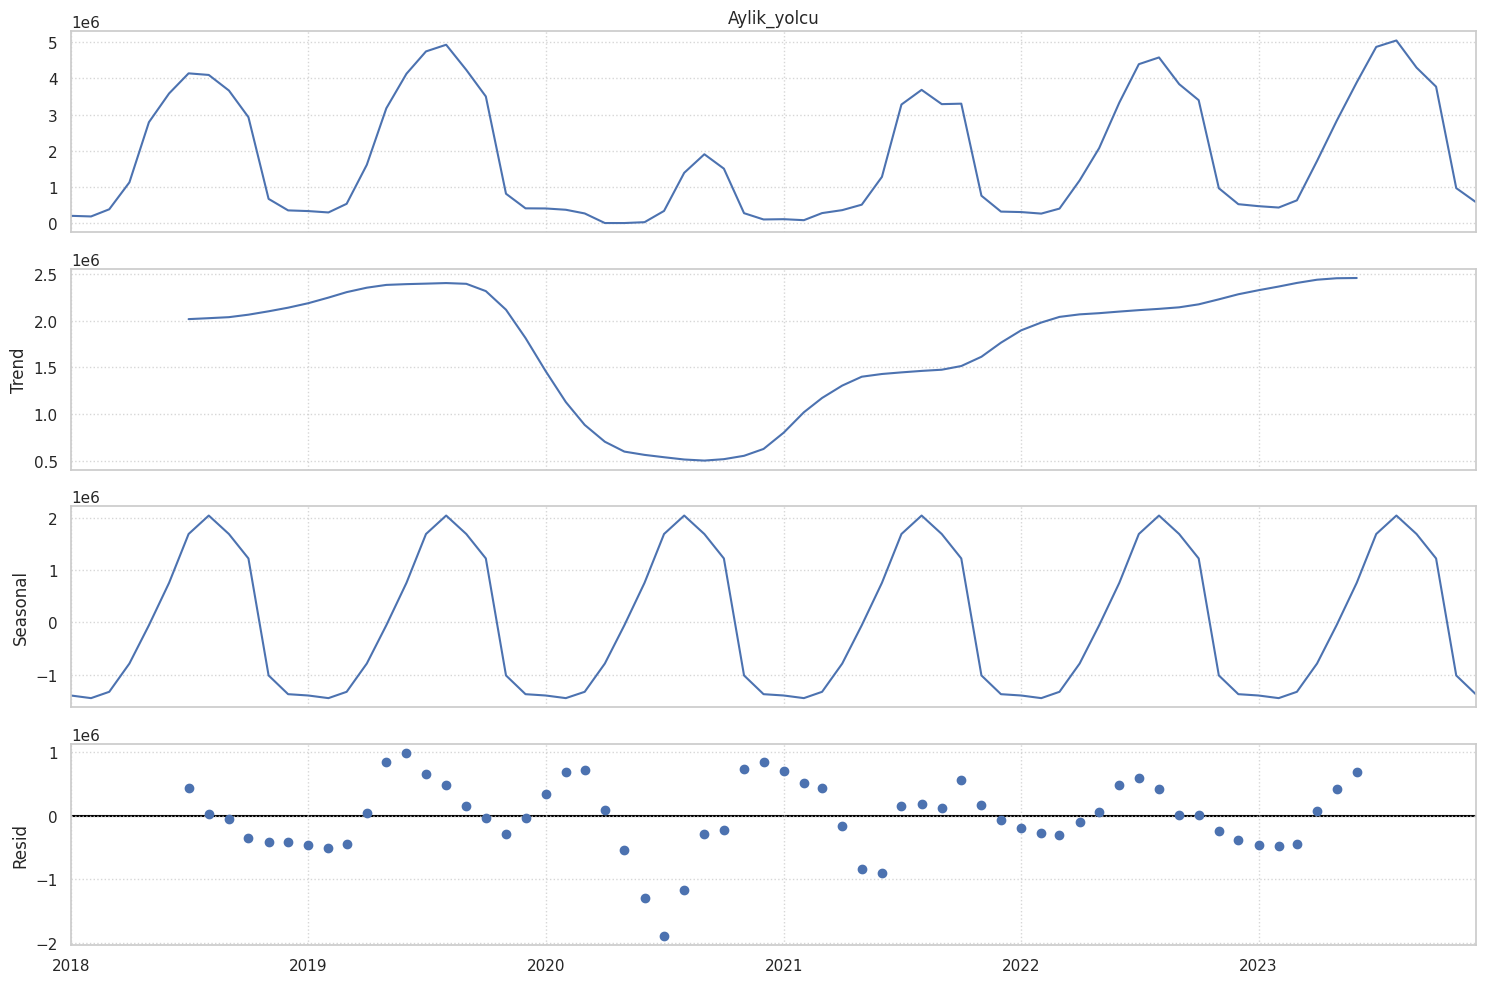

In [28]:
from matplotlib.lines import lineStyles
#--NEDEN ZAMAN SERİSİ AYRIŞTIRMASI (DECOMPOSITION) YAPIYORUZ?---
#1. Antalya Havalimanı verisinde çok güçlü bir yaz-kış döngüsü (mevsimsellik) bulunuyor,
#2. Amacımız,dış şokların gerçek etkisini,olağan kış düşüşlerinden matematiksel olarak ayırmak.
#3. Veriyi Trend, Mevsimsellik ve kalıntı olarak üç ana parçaya bölüyoruz.
#4. Böylece krizlerin izole edilmiş ayak izlerini sadece "kalıntı" bileşeninde , saf bir şok olarak görebileceğiz.
#Bu adım ,kuracağımız makine öğrenmesi modelinin mevsimsel düşüşleri kriz sanıp yanılmasını engeller.
import statsmodels.api as sm
df_ts=df_sorted.set_index("Tarih")
ayrisim=sm.tsa.seasonal_decompose(df_ts["Aylik_yolcu"],model="additive",period=12)
fig=ayrisim.plot()
fig.set_size_inches(15,10)
for ax in fig.axes:
  ax.grid(True,linestyle=":",alpha=0.8)
plt.tight_layout()
plt.show()


In [29]:
#1. HAM VERİMİZ
#2.TREND:2020 pandemisinde ve 2022'deki savaş döneminde truzmin uzun
#vadeligidişatının nasıl çakıldığını ve sonrasında nasıl tekrar yukarı
#tırmandığını net gösteren grafik
#3.SEASONAL:Her yıl yazın zirve yapıp kışın sıfıra yaklaşan o turizm döngüsü
#4.RESID: Mevsimsellik ve trendden tamamen temizlenmiş veri

In [34]:
from statsmodels.tsa.stattools import adfuller
#ayrıştırılan kalıntı bileşenini (şokları) ana veri çerçevemize yeni bir sütun olarak ekliyoruz
df_sorted["Kalinti"]=ayrisim.resid

In [62]:
# ADF testi ile kalıntının durağanları inceliyoruz
kalinti_temiz=pd.Series(ayrisim.resid).dropna()
adf_sonuc=adfuller(kalinti_temiz)

In [63]:
print("---ADF DURAĞANLIK TESTİ SONUÇLARI---")
print(f"ADF İstatistiği:{adf_sonuc[0]:.4f}")
print(f"p-değeri(p-value):{adf_sonuc[1]:.4f}")

if adf_sonuc[1]<0.05:
  print("Sonuç:Kalıntı serimiz durağandır.Modellemeye tamamen hazırdır")
else:
  print("Sonuç:Kalıntı serisi durağan değildir.")


---ADF DURAĞANLIK TESTİ SONUÇLARI---
ADF İstatistiği:-5.7883
p-değeri(p-value):0.0000
Sonuç:Kalıntı serimiz durağandır.Modellemeye tamamen hazırdır


In [68]:
#Etki Modellemesi(Regresyon Analizi)
df_sorted["Tarih"]=pd.to_datetime(df_sorted["Tarih"])

In [72]:
#şok dönemleri için kukla(dummy) değişkenler oluşturalım
df_sorted["covid_soku"]= ((df_sorted["Tarih"] >= "2020-03-01")&(df_sorted['Tarih']<="2020-12-31")).astype(int)
df_sorted["savas_soku"]= (df_sorted["Tarih"] >= "2022-02-01").astype(int)

In [74]:
#model için kullanılacak verileri hazırlayıp NaN değerleri filtreliyoruz
model_df=pd.DataFrame({
    "kalinti":pd.Series(ayrisim.resid).values,
    "covid_soku":df_sorted["covid_soku"].values,
    "savas_soku":df_sorted["savas_soku"].values

}).dropna()

In [75]:
#bağımlı değişkenimiz kalıntı ile bağımsız değişkenlerimiz şoklar ile regresyon(ols) modeli kuruyoruz
y=model_df["kalinti"]
X=model_df[["covid_soku","savas_soku"]]
X=sm.add_constant(X)


model=sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                kalinti   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     1.741
Date:                Fri, 14 Aug 2026   Prob (F-statistic):              0.185
Time:                        14:03:35   Log-Likelihood:                -877.10
No. Observations:                  60   AIC:                             1760.
Df Residuals:                      57   BIC:                             1766.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.058e+04   9.65e+04      0.732      0.4

In [76]:
#model performansı:model, varyansın %5.8'ini açıklamaktadır
#covid-19 şoku:pandemi ortalama 372.000 kişilik anlamlı bir trafik daralmasına yol açmıştır
#RUSYA-UKRAYNA Savaşı:savaşın etkisi negatif yönlü görülsede istatistiksel olarak anlamlı bulunmamıştır.

INFO:prophet:n_changepoints greater than number of observations. Using 19.


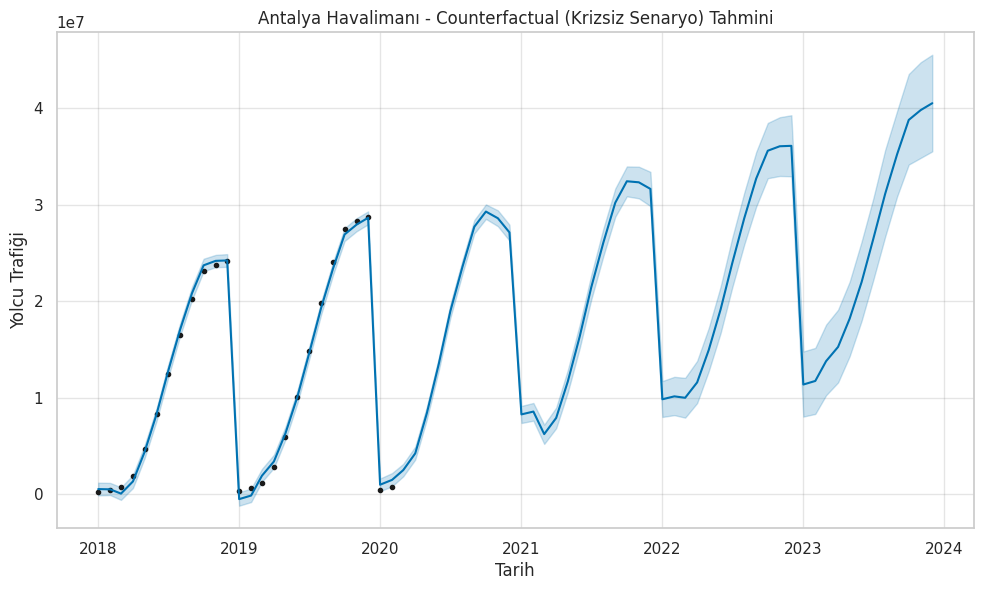

In [78]:
# ya pandemi ve savaş olmasaydı
from prophet import Prophet
import pandas as pd

# 1. Prophet için veri setini hazırlıyoruz (ds = Tarih, y = Hedef Değişken)
df_prophet = df_sorted[['Tarih', 'kumulatif_yolcu']].rename(columns={'Tarih': 'ds', 'kumulatif_yolcu': 'y'})

# 2. Sadece krizler *öncesi* normal dönemi modele öğretiyoruz ki krizin sapmasını görebilelim
# (Pandemi öncesi 2018 - 2020 başı arasındaki normal trendi öğreniyor)
train_prophet = df_prophet[df_prophet['ds'] < '2020-03-01']

model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(train_prophet)

# 3. Tüm tarih aralığı için (kriz dönemi dahil) gelecek tahmini üretiyoruz
future = model.make_future_dataframe(periods=len(df_prophet) - len(train_prophet), freq='MS')
forecast = model.predict(future)

# 4. Sonuçları görselleştirerek krizin yarattığı makası net bir şekilde çizdiriyoruz
fig = model.plot(forecast)
plt.title('Antalya Havalimanı - Counterfactual (Krizsiz Senaryo) Tahmini', fontsize=12)
plt.xlabel('Tarih')
plt.ylabel('Yolcu Trafiği')
plt.show()

In [79]:
# --- ANALİZ VE MODELLEME ÖZETİ ---
# 1. Ekonometrik Yaklaşım (OLS): Geçmiş dönem verileri üzerinde şok dönemleri (Covid-19, Jeopolitik Savaş)
# kukla değişkenlerle modellenmiş; pandemi döneminin trafik üzerinde istatistiksel olarak anlamlı
# bir negatif etki yarattığı doğrulanmıştır (p < 0.10).

# 2. Makine Öğrenmesi Yaklaşımı (Counterfactual Tahminleme): İstatistiksel modelleri desteklemek amacıyla,
# kriz öncesi dönemin verileriyle "krizsiz senaryo" (baseline) eğitilmiştir.
# Gerçekleşen trafik verisi ile modelin krizsiz senaryo tahmini arasındaki sapma (makas),
# jeopolitik şokların yolcu trafiği üzerindeki "net maliyetini" nicel olarak ortaya koymaktadır.

# 3. Yöntemsel Uyum: Hibrit (OLS + ML) bu yaklaşım, hem değişkenlerin nedensellik ilişkisini
# anlamlandırmakta (interpretability) hem de krizin yarattığı sapmanın büyüklüğünü tahminleme (predictive)
# yeteneğiyle veriye dayalı bir kanıt sunmaktadır.